In [3]:
import matplotlib.pyplot as plt
import pandas as pd

C:\Users\hjbec\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
%matplotlib inline

### Let's Start Plotting

In [4]:
url = ("https://raw.githubusercontent.com/pgarco/GESISPython2025/refs/heads/main/data/recent-grads.csv")

df = pd.read_csv(url)

In [ ]:
path = ("../../data/recent-grads.csv")

In [5]:
path = ("recent-grads.csv")

In [6]:
df = pd.read_csv(path)

In [7]:
df.head()

,Rank,Major_code,Major,Total,Men,Women,Major_category,ShareWomen,Sample_size,Employed,...,Part_time,Full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,College_jobs,Non_college_jobs,Low_wage_jobs
0,1,2419,PETROLEUM ENGINEERING,2339.0,2057.0,282.0,Engineering,0.120564,36,1976,...,270,1207,37,0.018381,110000,95000,125000,1534,364,193
1,2,2416,MINING AND MINERAL ENGINEERING,756.0,679.0,77.0,Engineering,0.101852,7,640,...,170,388,85,0.117241,75000,55000,90000,350,257,50
2,3,2415,METALLURGICAL ENGINEERING,856.0,725.0,131.0,Engineering,0.153037,3,648,...,133,340,16,0.024096,73000,50000,105000,456,176,0
3,4,2417,NAVAL ARCHITECTURE AND MARINE ENGINEERING,1258.0,1123.0,135.0,Engineering,0.107313,16,758,...,150,692,40,0.050125,70000,43000,80000,529,102,0
4,5,2405,CHEMICAL ENGINEERING,32260.0,21239.0,11021.0,Engineering,0.341631,289,25694,...,5180,16697,1672,0.061098,65000,50000,75000,18314,4440,972


In [9]:
df.columns

Index(['Rank', 'Major_code', 'Major', 'Total', 'Men', 'Women',
       'Major_category', 'ShareWomen', 'Sample_size', 'Employed', 'Full_time',
       'Part_time', 'Full_time_year_round', 'Unemployed', 'Unemployment_rate',
       'Median', 'P25th', 'P75th', 'College_jobs', 'Non_college_jobs',
       'Low_wage_jobs'],
      dtype='object')

- "Median" is the median earnings of full-time, year-round workers.
- "P25th" is the 25th percentile of earnings.
- "P75th" is the 75th percentile of earnings.
- "Rank" is the major’s rank by median earnings.

In [ ]:
plot.plot([1,2,4,5],[1,2,4,5])

Let's say I want to plot the earnings vs the Rank:

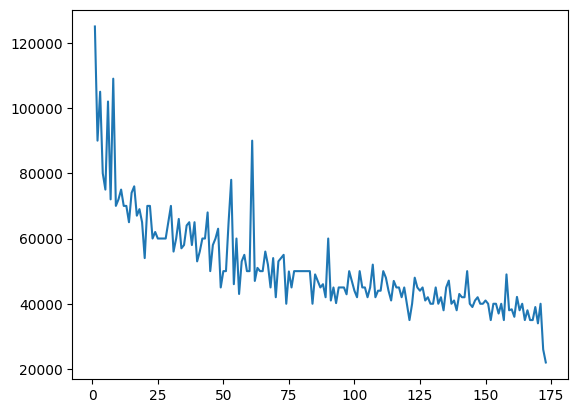

In [11]:
# I can do this easily with matplotlib

plt.plot(df["Rank"], df["P75th"])

In [ ]:
plt.show()

<Axes: xlabel='Rank'>

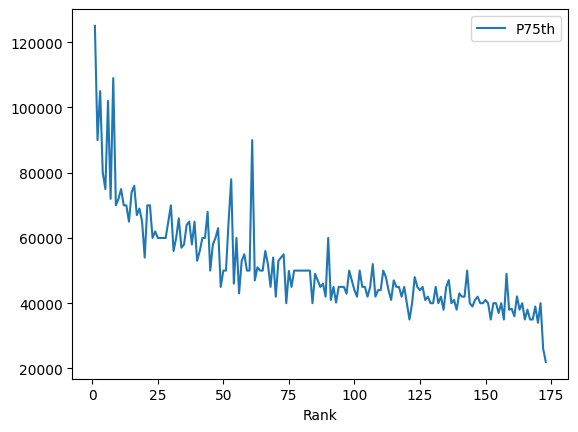

In [ ]:
#But Pandas lets me do this too, by providing a wrapper for matplotlib in the plot() method
df.plot(x="Rank", y="P75th")

<Axes: xlabel='Rank'>

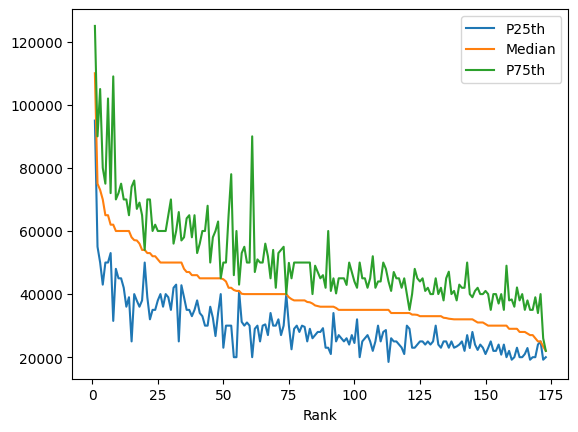

In [7]:
df.plot(x="Rank", y=["P25th", "Median", "P75th"])

The ``kind`` parameter accepts eleven different string values and determines which kind of plot you'll create. The default value is ``line``.

- **"area"** is for area plots.
- **"bar"** is for vertical bar charts.
- **"barh"** is for horizontal bar charts.
- **"box"** is for box plots.
- **"hexbin"** is for hexbin plots.
- **"hist"** is for histograms.
- **"kde"** is for kernel density estimate charts.
- **"density"** is an alias for "kde".
- **"line"** is for line graphs.
- **"pie"** is for pie charts.
- **"scatter"** is for scatter plots.

<Axes: xlabel='Rank'>

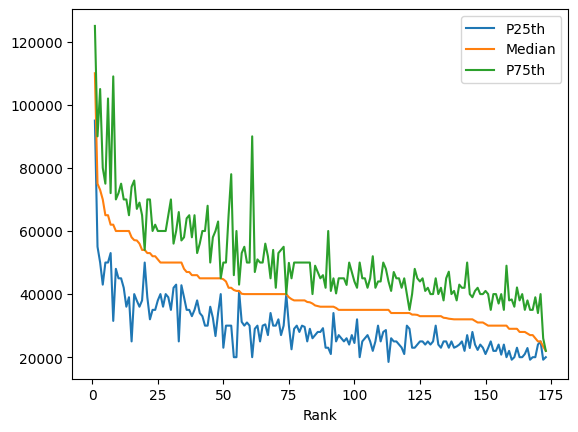

In [14]:
df.plot(x="Rank", y=["P25th", "Median", "P75th"], kind = "line")

## Distributions and Histograms

``DataFrame`` is not the only class in pandas with a ``.plot()`` method.

The ``Series`` object provides similar functionality.

In [ ]:
# And as it so happens, the column of dataframe is a series

median_column = df["Median"]

type(median_column)

pandas.core.series.Series

<Axes: ylabel='Frequency'>

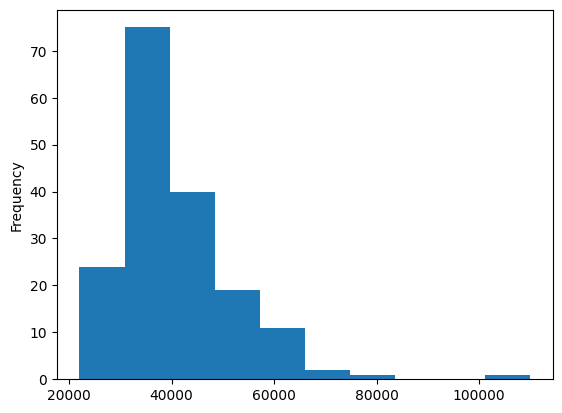

In [15]:
df["Median"].plot(kind="hist")

### Let's use a Bar tool to find out what's going with that really tiny group that's making six figures!


In [20]:
# First let's create a dataframe made of the top 5 careers

top_5 = df.sort_values(by="Median", ascending=False).head(5)

<Axes: xlabel='Major'>

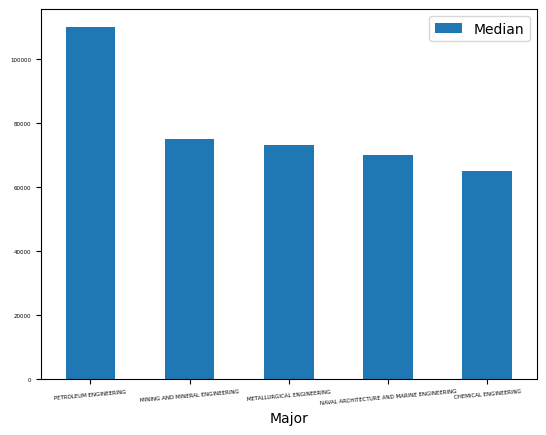

In [21]:
# Now we plot

top_5.plot(x="Major", y="Median", kind="bar", rot=5, fontsize=4)

Let's investigate all majors whose median salary is above $60,000. First, you need to filter these majors with ``` df[df["Median"] > 60000]```. Then you can create another bar plot showing all three earnings columns:



<Axes: xlabel='Major'>

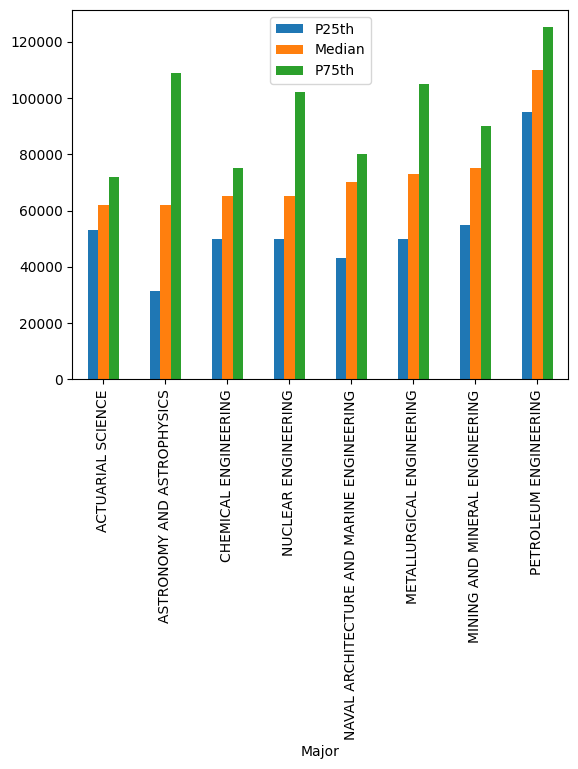

In [ ]:
top_medians = df[df["Median"] > 60000].sort_values("Median")

top_medians.plot(x="Major", y=["P25th", "Median", "P75th"], kind="bar")

## Checking for Correlation with Scatterplots

If you pick a major with higher median earnings, do you also have a lower chance of unemployment?

<Axes: xlabel='Median', ylabel='Unemployment_rate'>

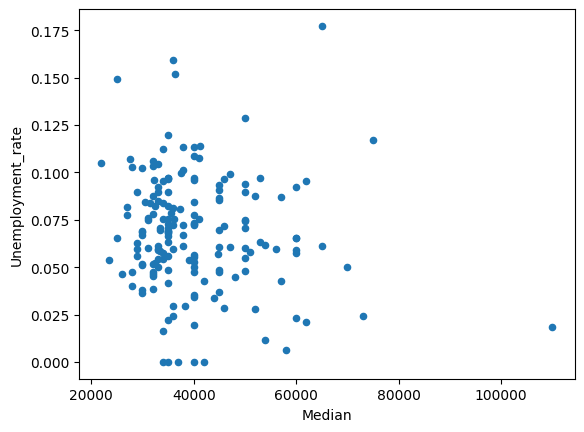

In [ ]:
df.plot(x="Median", y="Unemployment_rate", kind="scatter")

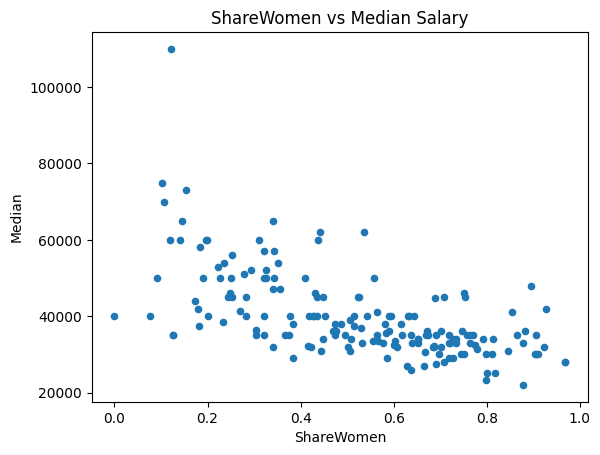

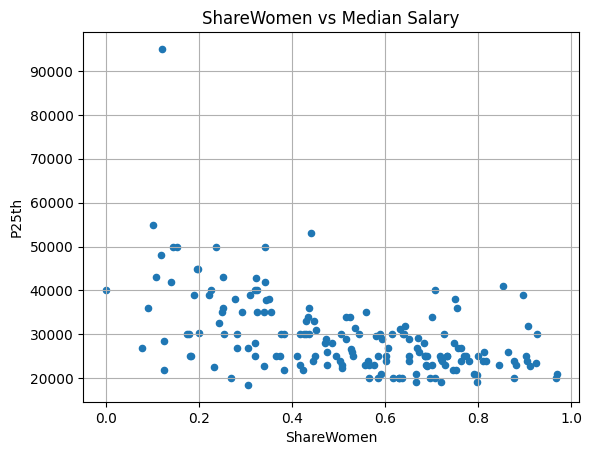

In [32]:
df.plot(x='ShareWomen', y='Median', kind='scatter', title='ShareWomen vs Median Salary')
df.plot(x='ShareWomen', y='P25th', kind='scatter', title='ShareWomen vs Median Salary')
plt.grid(True)



In [30]:

correlation = df['ShareWomen'].corr(df['Median'])
print("Correlation:",correlation)


Correlation: -0.6186897512131608


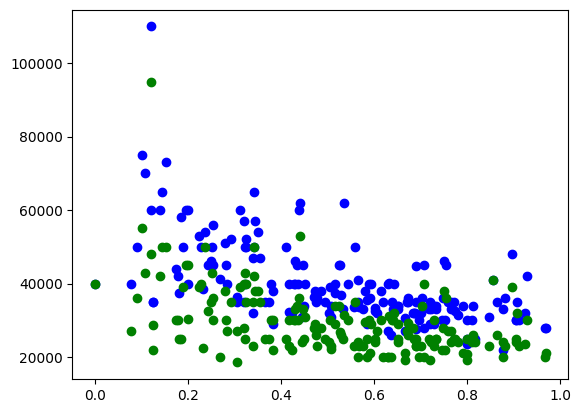

In [34]:

# First scatter: ShareWomen vs Median
plt.scatter(df['ShareWomen'], df['Median'], color='blue', label='ShareWomen vs Median')
plt.scatter(df['ShareWomen'], df['P25th'], color='green', label='ShareWomen vs Median')

